
# Hyperparameter Tuning with Cross-Validation — full source, executed


Real data throughout: `sklearn`'s **wine** dataset (178 samples, 13 chemical
measurements, 3 cultivars).


In [1]:

import json, os, sys, time, glob, shutil, subprocess, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import animation
from scipy.stats import norm, wilcoxon
from IPython.display import HTML, Image, Video, display

from sklearn.datasets import load_wine
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

warnings.filterwarnings("ignore")
np.random.seed(0)
%matplotlib inline

RUN_EXPERIMENTS = False   # True = recompute the 4 experiment scripts from scratch (slow)
CACHE = "cached_results"
FRAMES = "frames"          # where this run writes its own animation frames
os.makedirs(CACHE, exist_ok=True)
os.makedirs(FRAMES, exist_ok=True)
for sub in ["bo_frames", "hb_frames", "video_frames"]:
    os.makedirs(f"{FRAMES}/{sub}", exist_ok=True)



## 1. Setup, data, search space, model 

In [2]:

X, y = load_wine(return_X_y=True)
feature_names = load_wine().feature_names
print(f"X shape: {X.shape}   classes: {np.unique(y)}   samples/class: {np.bincount(y)}")

SEARCH_SPACE = {
    "learning_rate":    (0.01, 0.5, "log"),
    "max_depth":        (1, 6, "int"),
    "min_samples_leaf": (1, 20, "int"),
    "subsample":        (0.5, 1.0, "float"),
    "max_features":     (0.3, 1.0, "float"),
}
FULL_BUDGET = 100


def make_model(params, n_estimators):
    return make_pipeline(
        StandardScaler(),
        GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            subsample=params["subsample"],
            max_features=params["max_features"],
            random_state=0,
        ),
    )


def cv_score(params, n_estimators, cv, X_=X, y_=y):
    model = make_model(params, n_estimators)
    scores = cross_val_score(model, X_, y_, cv=cv, scoring="accuracy", n_jobs=1)
    return scores.mean()


def sample_params(random_state):
    r = np.random.default_rng(random_state)
    lr = float(np.exp(r.uniform(np.log(0.01), np.log(0.5))))
    d = int(r.integers(1, 7))
    leaf = int(r.integers(1, 21))
    sub = float(r.uniform(0.5, 1.0))
    mf = float(r.uniform(0.3, 1.0))
    return dict(learning_rate=lr, max_depth=d, min_samples_leaf=leaf, subsample=sub, max_features=mf)


def cost_of(n_estimators, n_folds=5):
    return n_estimators * n_folds


CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

default_params = dict(learning_rate=0.1, max_depth=3, min_samples_leaf=1, subsample=1.0, max_features=1.0)
default_score = cv_score(default_params, FULL_BUDGET, CV5)
print(f"Default (untuned) 5-fold CV accuracy: {default_score:.4f}  (deck headline: 94.9% -> 99.4%)")

pd.DataFrame(X, columns=feature_names).assign(cultivar=y).head()


X shape: (178, 13)   classes: [0 1 2]   samples/class: [59 71 48]


Default (untuned) 5-fold CV accuracy: 0.9494  (deck headline: 94.9% -> 99.4%)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



## 2. Grid search / Random search / Bayesian optimization (TPE)

A 3-level lattice grid
(3⁵ = 243 configs)
all scored with the same 5-fold CV at full fidelity.


In [ ]:

if RUN_EXPERIMENTS:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def log_grid(lo, hi, n): return np.exp(np.linspace(np.log(lo), np.log(hi), n))
    def lin_grid(lo, hi, n): return np.linspace(lo, hi, n)

    levels = 3
    grid_lr = log_grid(0.01, 0.5, levels)
    grid_depth = np.unique(np.round(lin_grid(1, 6, levels)).astype(int))
    grid_leaf = np.unique(np.round(lin_grid(1, 20, levels)).astype(int))
    grid_sub = lin_grid(0.5, 1.0, levels)
    grid_mf = lin_grid(0.3, 1.0, levels)

    grid_trials = []
    cum_cost = 0
    t0 = time.time()
    for lr in grid_lr:
        for d in grid_depth:
            for leaf in grid_leaf:
                for sub in grid_sub:
                    for mf in grid_mf:
                        params = dict(learning_rate=float(lr), max_depth=int(d), min_samples_leaf=int(leaf),
                                      subsample=float(sub), max_features=float(mf))
                        s = cv_score(params, FULL_BUDGET, CV5)
                        cum_cost += cost_of(FULL_BUDGET)
                        grid_trials.append({**params, "score": s, "cum_cost": cum_cost})
    print(f"Grid search: {len(grid_trials)} configs in {time.time()-t0:.1f}s, best={max(t['score'] for t in grid_trials):.4f}")

    N_TRIALS_BUDGET = len(grid_trials)

    random_trials = []
    cum_cost = 0
    t0 = time.time()
    for i in range(N_TRIALS_BUDGET):
        params = sample_params(1000 + i)
        s = cv_score(params, FULL_BUDGET, CV5)
        cum_cost += cost_of(FULL_BUDGET)
        random_trials.append({**params, "score": s, "cum_cost": cum_cost})
    print(f"Random search: {len(random_trials)} configs in {time.time()-t0:.1f}s, best={max(t['score'] for t in random_trials):.4f}")

    tpe_trials = []
    cum_cost = [0]

    def objective(trial):
        params = dict(
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
            max_depth=trial.suggest_int("max_depth", 1, 6),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            max_features=trial.suggest_float("max_features", 0.3, 1.0),
        )
        s = cv_score(params, FULL_BUDGET, CV5)
        cum_cost[0] += cost_of(FULL_BUDGET)
        tpe_trials.append({**params, "score": s, "cum_cost": cum_cost[0]})
        return s

    sampler = optuna.samplers.TPESampler(seed=42, n_startup_trials=10)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    t0 = time.time()
    study.optimize(objective, n_trials=N_TRIALS_BUDGET, show_progress_bar=False)
    print(f"TPE search: {len(tpe_trials)} configs in {time.time()-t0:.1f}s, best={max(t['score'] for t in tpe_trials):.4f}")

    with open(f"{CACHE}/search_grid.json", "w") as f: json.dump(grid_trials, f)
    with open(f"{CACHE}/search_random.json", "w") as f: json.dump(random_trials, f)
    with open(f"{CACHE}/search_tpe.json", "w") as f: json.dump(tpe_trials, f)
else:
    grid_trials = json.load(open(f"{CACHE}/search_grid.json"))
    random_trials = json.load(open(f"{CACHE}/search_random.json"))
    tpe_trials = json.load(open(f"{CACHE}/search_tpe.json"))
    print(f"Loaded cached results: grid={len(grid_trials)}, random={len(random_trials)}, tpe={len(tpe_trials)} trials")

print("Best 5-fold CV accuracy found:")
print(f"  Grid search           : {max(t['score'] for t in grid_trials):.4f}")
print(f"  Random search         : {max(t['score'] for t in random_trials):.4f}")
print(f"  Bayesian optimization : {max(t['score'] for t in tpe_trials):.4f}")


Loaded cached results: grid=243, random=243, tpe=243 trials
Best 5-fold CV accuracy found:
  Grid search           : 0.9943
  Random search         : 0.9889
  Bayesian optimization : 0.9944


## 3. Hyperband / successive halving 

In [4]:

if RUN_EXPERIMENTS:
    eta = 3
    min_budget, max_budget = 10, FULL_BUDGET
    n_rungs = int(np.floor(np.log(max_budget / min_budget) / np.log(eta))) + 1
    rung_budgets = [int(min_budget * (eta ** k)) for k in range(n_rungs)]
    rung_budgets[-1] = max_budget
    n0 = 81

    hb_trials = []
    cum_cost = 0
    configs = [sample_params(5000 + i) for i in range(n0)]
    alive_idx = list(range(len(configs)))
    rung_snapshots = []

    t0 = time.time()
    for rung, budget in enumerate(rung_budgets):
        scores = []
        for idx in alive_idx:
            s = cv_score(configs[idx], budget, CV5)
            cum_cost += cost_of(budget)
            scores.append(s)
            hb_trials.append({**configs[idx], "score": s, "budget": budget, "rung": rung, "cum_cost": cum_cost})
        order = np.argsort(scores)[::-1]
        keep_n = max(1, len(alive_idx) // eta) if rung < len(rung_budgets) - 1 else 1
        survivors_mask = np.zeros(len(alive_idx), dtype=bool)
        survivors_mask[order[:keep_n]] = True
        rung_snapshots.append({"budget": budget, "scores": scores,
                                "survivors_mask": survivors_mask.tolist(), "n_alive": len(alive_idx)})
        alive_idx = [alive_idx[i] for i in order[:keep_n]]
        print(f"  rung {rung}: budget={budget:>3}  evaluated={len(scores):>2}  best={max(scores):.4f}  kept={keep_n}")

    best_hb = max(hb_trials, key=lambda t: t["score"])
    print(f"Hyperband total cost={cum_cost}, n_evals={len(hb_trials)}, best={best_hb['score']:.4f}, time={time.time()-t0:.1f}s")

    with open(f"{CACHE}/search_hyperband.json", "w") as f:
        json.dump({"trials": hb_trials, "rung_snapshots": rung_snapshots, "rung_budgets": rung_budgets}, f)
else:
    hb_data = json.load(open(f"{CACHE}/search_hyperband.json"))
    hb_trials = hb_data["trials"]
    rung_snapshots = hb_data["rung_snapshots"]
    rung_budgets = hb_data["rung_budgets"]
    print(f"Loaded cached Hyperband run: {len(hb_trials)} fits across {len(rung_snapshots)} rungs, budgets={rung_budgets}")
    for i, snap in enumerate(rung_snapshots):
        print(f"  rung {i}: budget={snap['budget']:>3}  evaluated={snap['n_alive']:>2}  best={max(snap['scores']):.4f}")

speedup = grid_trials[-1]["cum_cost"] / hb_trials[-1]["cum_cost"]
print(f"\nHyperband used about {speedup:.1f}x less compute than grid/random/BO's per-trial budget.")


Loaded cached Hyperband run: 117 fits across 3 rungs, budgets=[10, 30, 100]
  rung 0: budget= 10  evaluated=81  best=0.9887
  rung 1: budget= 30  evaluated=27  best=0.9889
  rung 2: budget=100  evaluated= 9  best=0.9832

Hyperband used about 9.6x less compute than grid/random/BO's per-trial budget.


## 4. All 7 static figures, exact deck styling

In [5]:

# ---- style.py (validated categorical palette used throughout the deck) ----
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, VIOLET, RED = \
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7", "#e34948"
INK, INK_SECOND, MUTED, GRID, BASELINE, SURFACE = \
    "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
CAT_ORDER = [BLUE, ORANGE, AQUA, VIOLET, MAGENTA, YELLOW]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK_SECOND, "ytick.color": INK_SECOND, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.family": "DejaVu Sans", "font.size": 13, "axes.titlesize": 16,
    "axes.titleweight": "bold", "axes.titlecolor": INK, "axes.labelsize": 13,
    "legend.frameon": False, "legend.fontsize": 11.5, "figure.dpi": 110,
    "savefig.dpi": 200, "axes.spines.top": False, "axes.spines.right": False,
})

def clean_ax(ax):
    ax.spines["left"].set_color(BASELINE)
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(length=0)
    return ax

FIGS = "figs_out"
os.makedirs(FIGS, exist_ok=True)

grid, rand, tpe, hb = grid_trials, random_trials, tpe_trials, hb_trials
d_bias = np.load(f"{CACHE}/nested_vs_nonnested.npz") if os.path.exists(f"{CACHE}/nested_vs_nonnested.npz") else None
d_resh = np.load(f"{CACHE}/reshuffling.npz") if os.path.exists(f"{CACHE}/reshuffling.npz") else None


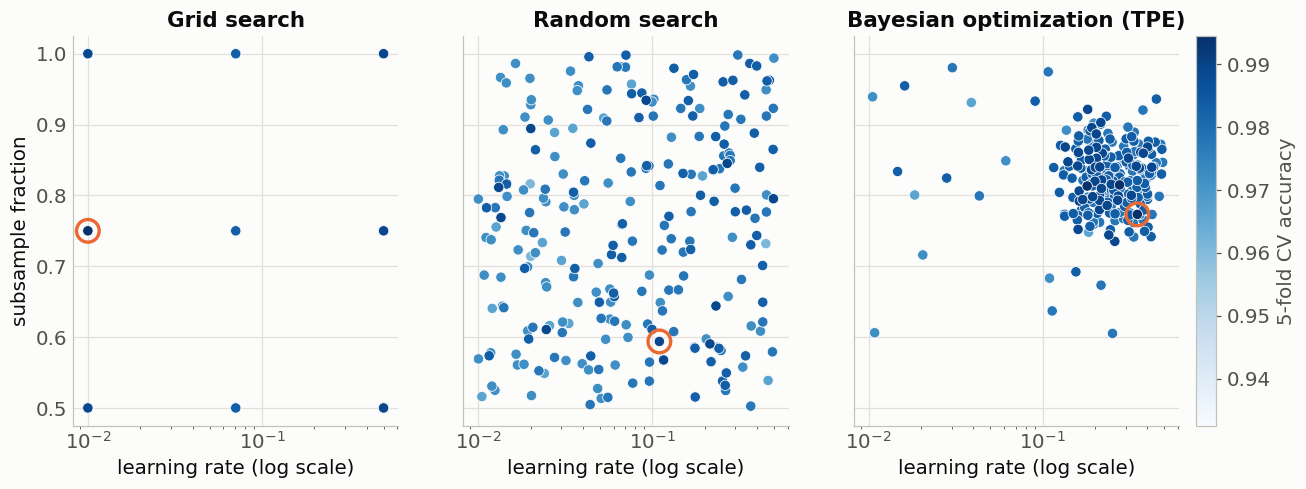

In [6]:

# FIG 1 -- search-space coverage: grid vs random vs Bayesian optimization
# Sort ascending by score so overlapping trials draw the best one LAST (on
# top), instead of a weaker overlapping trial hiding the true best.
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharex=True, sharey=True)
panels = [("Grid search", grid, BLUE), ("Random search", rand, ORANGE), ("Bayesian optimization (TPE)", tpe, AQUA)]
vmin = min(min(t["score"] for t in g) for _, g, _ in panels)
vmax = max(max(t["score"] for t in g) for _, g, _ in panels)
sc = None
for ax, (title, tri, color) in zip(axes, panels):
    tri_plot = sorted(tri, key=lambda t: t["score"])
    lr = [t["learning_rate"] for t in tri_plot]; sub = [t["subsample"] for t in tri_plot]; sco = [t["score"] for t in tri_plot]
    sc = ax.scatter(lr, sub, c=sco, cmap="Blues", vmin=vmin, vmax=vmax, s=46, edgecolors="white", linewidths=0.5, zorder=3)
    best = tri[int(np.argmax([t["score"] for t in tri]))]
    ax.scatter([best["learning_rate"]], [best["subsample"]], s=220, facecolors="none", edgecolors=ORANGE, linewidths=2.2, zorder=4)
    ax.set_xscale("log"); ax.set_title(title, fontsize=14); ax.set_xlabel("learning rate (log scale)")
    clean_ax(ax)
axes[0].set_ylabel("subsample fraction")
cbar = fig.colorbar(sc, ax=axes, fraction=0.024, pad=0.015); cbar.set_label("5-fold CV accuracy", color=INK_SECOND)
fig.savefig(f"{FIGS}/fig1_search_space.png", bbox_inches="tight")
plt.show()


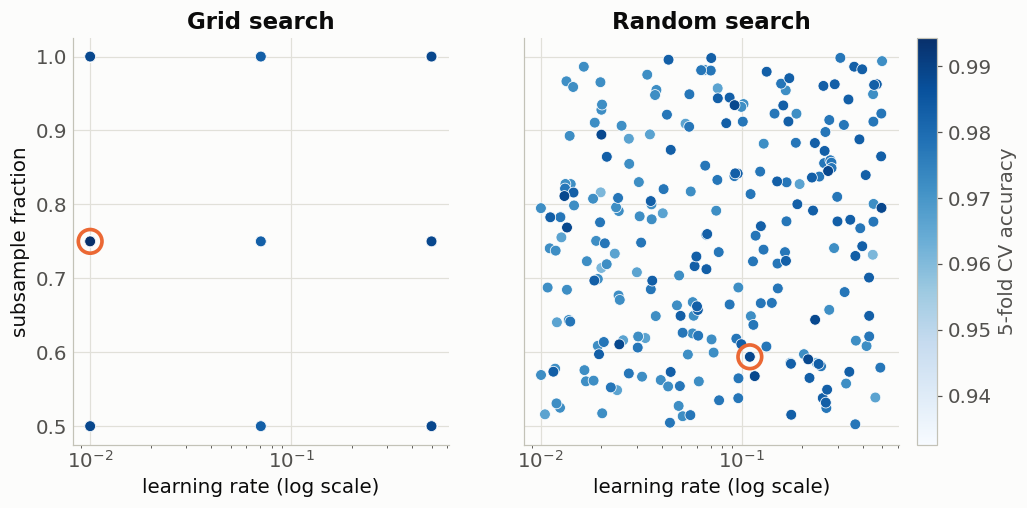

In [7]:

# FIG 1a -- search-space coverage: grid vs random ONLY (used before BO is introduced)
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.8), sharex=True, sharey=True)
panels2 = [("Grid search", grid, BLUE), ("Random search", rand, ORANGE)]
vmin2 = min(min(t["score"] for t in g) for _, g, _ in panels2)
vmax2 = max(max(t["score"] for t in g) for _, g, _ in panels2)
sc2 = None
for ax, (title, tri, color) in zip(axes, panels2):
    tri_plot = sorted(tri, key=lambda t: t["score"])
    lr = [t["learning_rate"] for t in tri_plot]; sub = [t["subsample"] for t in tri_plot]; sco = [t["score"] for t in tri_plot]
    sc2 = ax.scatter(lr, sub, c=sco, cmap="Blues", vmin=vmin2, vmax=vmax2, s=50, edgecolors="white", linewidths=0.5, zorder=3)
    best = tri[int(np.argmax([t["score"] for t in tri]))]
    ax.scatter([best["learning_rate"]], [best["subsample"]], s=240, facecolors="none", edgecolors=ORANGE, linewidths=2.4, zorder=4)
    ax.set_xscale("log"); ax.set_title(title, fontsize=15); ax.set_xlabel("learning rate (log scale)")
    clean_ax(ax)
axes[0].set_ylabel("subsample fraction")
cbar2 = fig.colorbar(sc2, ax=axes, fraction=0.03, pad=0.02); cbar2.set_label("5-fold CV accuracy", color=INK_SECOND)
fig.savefig(f"{FIGS}/fig1a_grid_random.png", bbox_inches="tight")
plt.show()


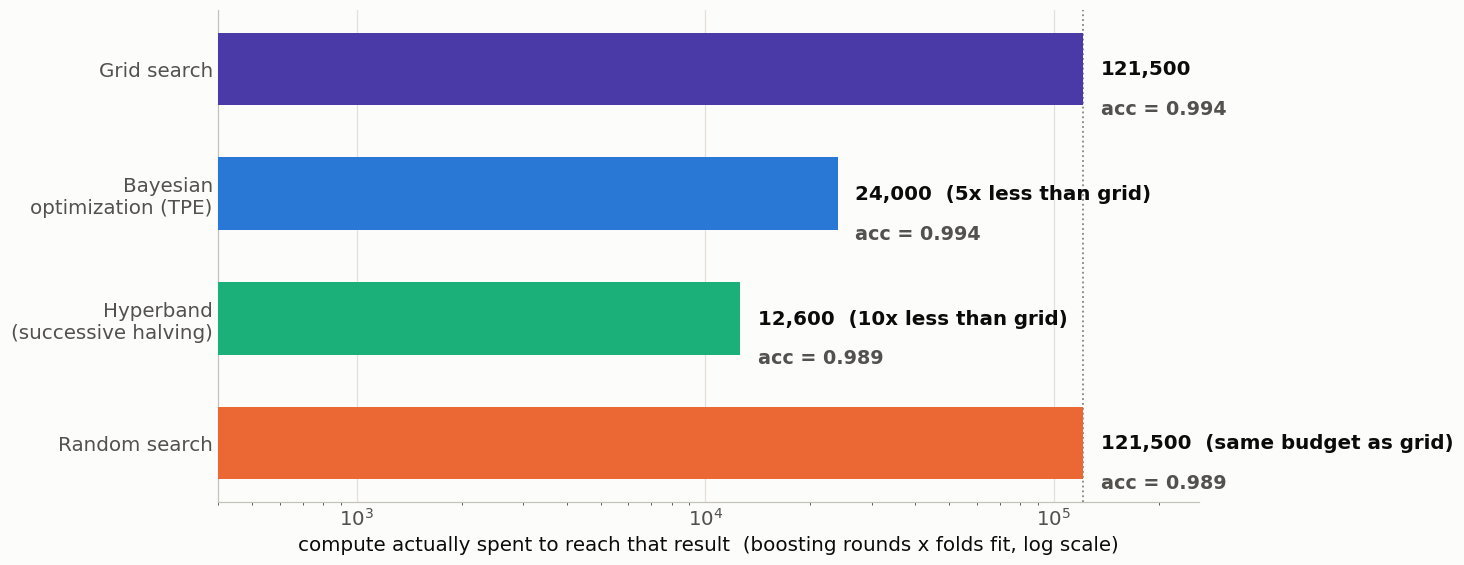

In [ ]:

def running_best(tri, cost_key="cum_cost"):
    tri_sorted = sorted(tri, key=lambda t: t[cost_key])
    xs, ys, best = [], [], -np.inf
    for t in tri_sorted:
        best = max(best, t["score"]); xs.append(t[cost_key]); ys.append(best)
    return np.array(xs), np.array(ys)

grid_budget = grid[-1]["cum_cost"]; grid_acc = max(t["score"] for t in grid); grid_n = len(grid)
rand_budget = rand[-1]["cum_cost"]; rand_acc = max(t["score"] for t in rand); rand_n = len(rand)
bo_reach_cost, bo_reach_acc, bo_reach_n = None, -1, None
_best = -1
for i, t in enumerate(sorted(tpe, key=lambda t: t["cum_cost"])):
    if t["score"] > _best:
        _best = t["score"]; bo_reach_cost, bo_reach_acc, bo_reach_n = t["cum_cost"], t["score"], i + 1
hb_budget = hb[-1]["cum_cost"]; hb_acc = max(t["score"] for t in hb); hb_n = len(hb)

rows = [
    ("Random search",                   rand_budget,   rand_acc,      rand_n,      ORANGE),
    ("Hyperband\n(successive halving)", hb_budget,     hb_acc,        hb_n,        AQUA),
    ("Bayesian\noptimization (TPE)",     bo_reach_cost, bo_reach_acc,  bo_reach_n,  BLUE),
    ("Grid search",                     grid_budget,   grid_acc,      grid_n,      VIOLET),
]

fig, ax = plt.subplots(figsize=(11.5, 5.8))
y_pos = np.arange(len(rows))
costs = [r[1] for r in rows]
bars = ax.barh(y_pos, costs, color=[r[4] for r in rows], height=0.58, zorder=3)
ax.set_yticks(y_pos); ax.set_yticklabels([r[0] for r in rows], fontsize=13)
ax.set_xscale("log"); ax.set_xlim(400, 260000)
ax.set_xlabel("compute actually spent to reach that result  (boosting rounds x folds fit, log scale)")
clean_ax(ax); ax.grid(axis="y", visible=False)
ax.axvline(grid_budget, color=MUTED, linewidth=1.2, linestyle=":", zorder=1)
for y, (name, cost, acc, n, color) in zip(y_pos, rows):
    mult = grid_budget / cost
    if name == "Grid search":
        mult_txt = ""
    elif name == "Random search":
        mult_txt = "  (same budget as grid)"
    else:
        mult_txt = f"  ({mult:.0f}x less than grid)"
    ax.text(cost * 1.12, y, f"{cost:,.0f}{mult_txt}", va="center", ha="left", fontsize=13, color=INK, fontweight="bold")
    ax.text(cost * 1.12, y - 0.32, f"acc = {acc:.3f}", va="center", ha="left", fontsize=12.5, color=INK_SECOND, fontweight="bold")
fig.savefig(f"{FIGS}/fig2_convergence.png", bbox_inches="tight")
plt.show()


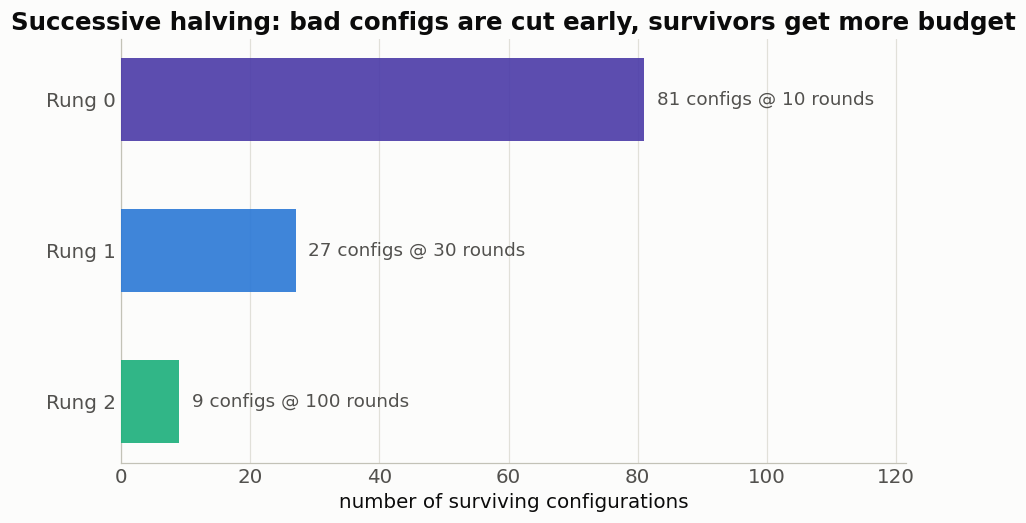

In [9]:

# FIG 3 -- Hyperband elimination funnel (static reference frame)
fig, ax = plt.subplots(figsize=(9.2, 5.0))
n_rungs = len(rung_snapshots)
colors = [VIOLET, BLUE, AQUA, ORANGE]
for i, snap in enumerate(rung_snapshots):
    n = snap["n_alive"]; yb = n_rungs - i
    ax.barh(yb, n, height=0.55, color=colors[i % len(colors)], alpha=0.9, zorder=3)
    ax.text(n + 2, yb, f"{n} configs @ {snap['budget']} rounds", va="center", fontsize=12, color=INK_SECOND)
ax.set_yticks([n_rungs - i for i in range(n_rungs)])
ax.set_yticklabels([f"Rung {i}" for i in range(n_rungs)])
ax.set_xlabel("number of surviving configurations")
ax.set_xlim(0, max(s["n_alive"] for s in rung_snapshots) * 1.5)
ax.set_title("Successive halving: bad configs are cut early, survivors get more budget")
clean_ax(ax); ax.grid(axis="y", visible=False)
fig.savefig(f"{FIGS}/fig3_hyperband_funnel.png", bbox_inches="tight")
plt.show()


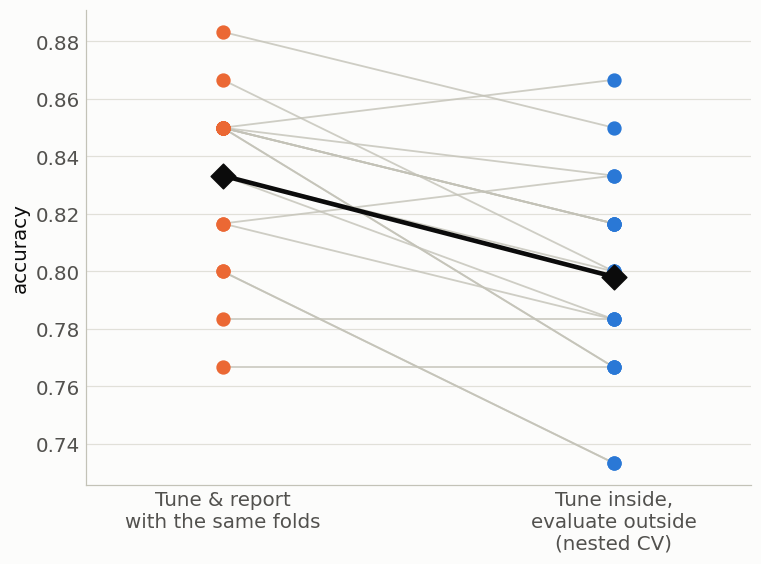

non-nested mean=0.8333  nested mean=0.7981  bias=+3.5pp


In [ ]:

if RUN_EXPERIMENTS:
    non_nested, nested = np.array(non_nested_reported), np.array(nested_honest)  # defined in section 5
else:
    non_nested, nested = d_bias["non_nested"], d_bias["nested"]

fig, ax = plt.subplots(figsize=(7.8, 5.6))
for a, b in zip(non_nested, nested):
    ax.plot([0, 1], [a, b], color=BASELINE, linewidth=1.2, zorder=1, alpha=0.8)
ax.scatter([0]*len(non_nested), non_nested, color=ORANGE, s=70, zorder=3, label="Non-nested (reused CV)")
ax.scatter([1]*len(nested), nested, color=BLUE, s=70, zorder=3, label="Nested CV (honest)")
ax.plot([0, 1], [np.mean(non_nested), np.mean(nested)], color=INK, linewidth=3, zorder=4)
ax.scatter([0, 1], [np.mean(non_nested), np.mean(nested)], color=INK, s=130, zorder=5, marker="D")
gap = np.mean(non_nested) - np.mean(nested)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Tune & report\nwith the same folds", "Tune inside,\nevaluate outside\n(nested CV)"])
ax.set_ylabel("accuracy")
# No matplotlib title/annotation here -- the slide's own title and take-home
# strip carry that text, so a baked-in title/label just duplicated it.
ax.set_xlim(-0.35, 1.35); clean_ax(ax); ax.grid(axis="x", visible=False)
fig.savefig(f"{FIGS}/fig4_nested_bias.png", bbox_inches="tight")
plt.show()
print(f"non-nested mean={np.mean(non_nested):.4f}  nested mean={np.mean(nested):.4f}  bias=+{gap*100:.1f}pp")


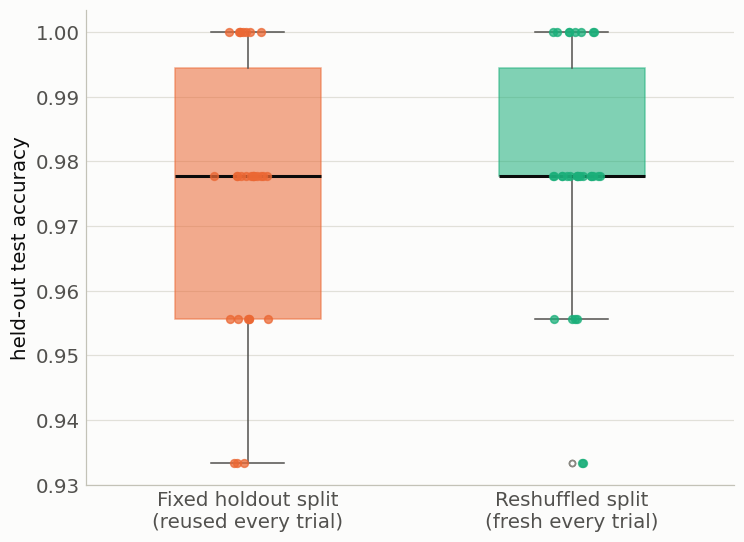

In [11]:

# FIG 5 -- reshuffling resampling splits (Nagler, Schneider, Bischl & Feurer, NeurIPS 2024)
if RUN_EXPERIMENTS:
    fixed, reshuf = np.array(fixed_test_scores), np.array(reshuf_test_scores)  # defined in section 6
else:
    fixed, reshuf = d_resh["fixed"], d_resh["reshuffled"]

fig, ax = plt.subplots(figsize=(7.6, 5.6))
bp = ax.boxplot([fixed, reshuf], positions=[0, 1], widths=0.45, patch_artist=True,
                 medianprops=dict(color=INK, linewidth=2), whiskerprops=dict(color=INK_SECOND),
                 capprops=dict(color=INK_SECOND), flierprops=dict(markeredgecolor=MUTED, markersize=4))
for patch, c in zip(bp["boxes"], [ORANGE, AQUA]):
    patch.set_facecolor(c); patch.set_alpha(0.55); patch.set_edgecolor(c)
rng = np.random.default_rng(0)
ax.scatter(rng.normal(0, 0.045, len(fixed)), fixed, color=ORANGE, s=26, alpha=0.75, zorder=3)
ax.scatter(rng.normal(1, 0.045, len(reshuf)), reshuf, color=AQUA, s=26, alpha=0.75, zorder=3)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Fixed holdout split\n(reused every trial)", "Reshuffled split\n(fresh every trial)"])
ax.set_ylabel("held-out test accuracy")
# No matplotlib title here -- the slide already has its own.
clean_ax(ax); ax.grid(axis="x", visible=False)
fig.savefig(f"{FIGS}/fig5_reshuffling.png", bbox_inches="tight")
plt.show()


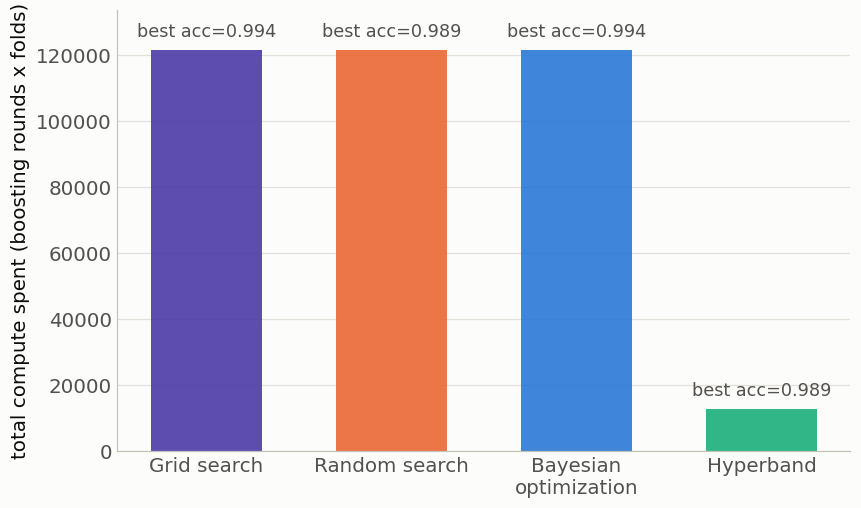

All figures saved to figs_out


In [ ]:

totals = {
    "Grid search": (grid[-1]["cum_cost"], max(t["score"] for t in grid)),
    "Random search": (rand[-1]["cum_cost"], max(t["score"] for t in rand)),
    "Bayesian\noptimization": (tpe[-1]["cum_cost"], max(t["score"] for t in tpe)),
    "Hyperband": (hb[-1]["cum_cost"], max(t["score"] for t in hb)),
}
fig, ax = plt.subplots(figsize=(8.6, 5.2))
names = list(totals.keys()); costs = [totals[n][0] for n in names]; scores = [totals[n][1] for n in names]
bars = ax.bar(names, costs, color=[VIOLET, ORANGE, BLUE, AQUA], alpha=0.9, width=0.6)
for bar, s in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(costs)*0.035, f"best acc={s:.3f}", ha="center", fontsize=11.5, color=INK_SECOND)
ax.set_ylabel("total compute spent (boosting rounds x folds)")

ax.set_ylim(0, max(costs) * 1.10)
clean_ax(ax); ax.grid(axis="x", visible=False)
fig.savefig(f"{FIGS}/fig6_cost_bar.png", bbox_inches="tight")
plt.show()
print("All figures saved to", FIGS)


## 5. Nested vs. non-nested CV 

In [13]:

if RUN_EXPERIMENTS:
    rng = np.random.default_rng(42)
    n_noise = 150
    X_weak = X[:, :2]
    X_noise = rng.normal(size=(X.shape[0], n_noise))
    X_aug = np.hstack([X_weak, X_noise])
    sub_idx = rng.choice(len(y), size=60, replace=False)
    Xs, ys = X_aug[sub_idx], y[sub_idx]

    N_CONFIGS_BIAS, BUDGET, N_REPEATS = 14, 30, 18
    bias_configs = [sample_params(7000 + i) for i in range(N_CONFIGS_BIAS)]
    non_nested_reported, nested_honest = [], []

    t0 = time.time()
    for rep in range(N_REPEATS):
        outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rep)
        inner_scores = [cv_score(p, BUDGET, outer_cv, Xs, ys) for p in bias_configs]
        non_nested_reported.append(inner_scores[int(np.argmax(inner_scores))])

        fold_test_scores = []
        for tr_idx, te_idx in outer_cv.split(Xs, ys):
            X_tr, X_te, y_tr, y_te = Xs[tr_idx], Xs[te_idx], ys[tr_idx], ys[te_idx]
            inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=rep)
            best_s, best_p = -1, None
            for p in bias_configs:
                s = cv_score(p, BUDGET, inner_cv, X_tr, y_tr)
                if s > best_s: best_s, best_p = s, p
            m = make_model(best_p, BUDGET); m.fit(X_tr, y_tr)
            fold_test_scores.append(m.score(X_te, y_te))
        nested_honest.append(float(np.mean(fold_test_scores)))
    print(f"{N_REPEATS} repeats in {time.time()-t0:.1f}s")
    np.savez(f"{CACHE}/nested_vs_nonnested.npz", non_nested=np.array(non_nested_reported), nested=np.array(nested_honest))
else:
    non_nested_reported, nested_honest = list(d_bias["non_nested"]), list(d_bias["nested"])

gap = np.mean(non_nested_reported) - np.mean(nested_honest)
stat, p = wilcoxon(non_nested_reported, nested_honest)
print(f"Non-nested (reused folds) mean : {np.mean(non_nested_reported):.4f}")
print(f"Nested CV (honest) mean        : {np.mean(nested_honest):.4f}")
print(f"Optimistic bias                : +{gap*100:.1f} percentage points")
print(f"Wilcoxon signed-rank: statistic={stat:.1f}, p={p:.4f}")


Non-nested (reused folds) mean : 0.8333
Nested CV (honest) mean        : 0.7981
Optimistic bias                : +3.5 percentage points
Wilcoxon signed-rank: statistic=7.0, p=0.0010


## 6. Reshuffling resampling splits — `01d_reshuffling.py`

In [14]:

if RUN_EXPERIMENTS:
    N_REPEATS_RS, N_CONFIGS_RS = 30, 40
    fixed_test_scores, reshuf_test_scores = [], []
    rs_configs = [sample_params(9000 + i) for i in range(N_CONFIGS_RS)]

    for rep in range(N_REPEATS_RS):
        X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=rep)

        X_tr_f, X_val_f, y_tr_f, y_val_f = train_test_split(X_dev, y_dev, test_size=0.3, stratify=y_dev, random_state=rep)
        best_s, best_p = -1, None
        for p in rs_configs:
            m = make_model(p, 60); m.fit(X_tr_f, y_tr_f)
            s = m.score(X_val_f, y_val_f)
            if s > best_s: best_s, best_p = s, p
        m = make_model(best_p, 60); m.fit(X_dev, y_dev)
        fixed_test_scores.append(m.score(X_test, y_test))

        best_s, best_p = -1, None
        for j, p in enumerate(rs_configs):
            X_tr_r, X_val_r, y_tr_r, y_val_r = train_test_split(X_dev, y_dev, test_size=0.3, stratify=y_dev, random_state=rep*1000+j)
            m = make_model(p, 60); m.fit(X_tr_r, y_tr_r)
            s = m.score(X_val_r, y_val_r)
            if s > best_s: best_s, best_p = s, p
        m = make_model(best_p, 60); m.fit(X_dev, y_dev)
        reshuf_test_scores.append(m.score(X_test, y_test))
    np.savez(f"{CACHE}/reshuffling.npz", fixed=np.array(fixed_test_scores), reshuffled=np.array(reshuf_test_scores))
else:
    fixed_test_scores, reshuf_test_scores = list(d_resh["fixed"]), list(d_resh["reshuffled"])

stat, p = wilcoxon(fixed_test_scores, reshuf_test_scores)
print(f"Fixed-split test accuracy      : mean={np.mean(fixed_test_scores):.4f}  std={np.std(fixed_test_scores):.4f}")
print(f"Reshuffled-split test accuracy : mean={np.mean(reshuf_test_scores):.4f}  std={np.std(reshuf_test_scores):.4f}")
print(f"Wilcoxon signed-rank: statistic={stat:.1f}, p={p:.4f}")


Fixed-split test accuracy      : mean=0.9748  std=0.0205
Reshuffled-split test accuracy : mean=0.9778  std=0.0181
Wilcoxon signed-rank: statistic=12.0, p=0.3883



## 7. Bayesian-optimization animation


In [15]:

rng = np.random.default_rng(7)

def true_f(x):
    return (0.62 * np.exp(-(x - 1.1) ** 2 / 0.9)
            + 0.30 * np.exp(-(x + 1.6) ** 2 / 1.3)
            + 0.05 * np.sin(2.6 * x) * np.exp(-0.04 * x ** 2)
            + 0.30)

X_dom = np.linspace(-3, 3, 400).reshape(-1, 1)
y_true = true_f(X_dom.ravel())
y_min, y_max = 0.55, 1.0

def to_acc(v):
    return y_min + (v - y_true.min()) / (y_true.max() - y_true.min()) * (y_max - y_min)

y_true_acc = to_acc(y_true)

def observe(x):
    return to_acc(true_f(np.array([x])))[0] + rng.normal(0, 0.006)

X_obs = list(rng.uniform(-2.6, 2.6, size=3))
y_obs = [observe(x) for x in X_obs]
kernel = C(0.05, (1e-3, 1)) * RBF(length_scale=0.9, length_scale_bounds=(0.2, 3.0)) + WhiteKernel(1e-4, (1e-6, 1e-2))

N_ITERS = 11
bo_frame_files = []

for it in range(N_ITERS):
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=3, random_state=0)
    gp.fit(np.array(X_obs).reshape(-1, 1), np.array(y_obs))
    mu, sigma = gp.predict(X_dom, return_std=True)

    best_y = max(y_obs)
    with np.errstate(divide="ignore"):
        imp = mu - best_y - 0.01
        Z = imp / np.where(sigma > 1e-9, sigma, 1e-9)
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma < 1e-9] = 0.0
    next_x = X_dom[np.argmax(ei), 0]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.6, 6.6), height_ratios=[2.4, 1], sharex=True)
    ax1.plot(X_dom, y_true_acc, "--", color=MUTED, linewidth=1.6, label="true validation surface (unknown to the optimizer)")
    ax1.plot(X_dom, mu, color=BLUE, linewidth=2.4, label="surrogate model (GP posterior mean)")
    ax1.fill_between(X_dom.ravel(), mu - 1.96*sigma, mu + 1.96*sigma, color=BLUE, alpha=0.18, label="surrogate uncertainty (95%)")
    ax1.scatter(X_obs, y_obs, color=INK, s=70, zorder=5, label="evaluated configurations")
    if it < N_ITERS - 1:
        ax1.scatter([next_x], [to_acc(true_f(np.array([next_x])))[0]], marker="*", s=340, color=ORANGE,
                    edgecolors=INK, linewidths=0.6, zorder=6, label="next configuration to try")
    ax1.set_ylim(y_min - 0.03, y_max + 0.05); ax1.set_ylabel("cross-validated accuracy")
    ax1.set_title(f"Bayesian optimization -- iteration {it+1} / {N_ITERS}", fontsize=15)
    ax1.legend(loc="lower center", ncol=2, fontsize=9.6, bbox_to_anchor=(0.5, -0.04)); clean_ax(ax1)

    ax2.fill_between(X_dom.ravel(), 0, ei, color=AQUA, alpha=0.55)
    ax2.plot(X_dom, ei, color=AQUA, linewidth=1.6)
    if it < N_ITERS - 1:
        ax2.axvline(next_x, color=ORANGE, linewidth=1.8, linestyle=":")
    ax2.set_ylabel("expected\nimprovement"); ax2.set_xlabel("hyperparameter (e.g. log10(learning rate))")
    ax2.set_ylim(bottom=0); clean_ax(ax2)

    fig.tight_layout()
    fname = f"{FRAMES}/bo_frames/frame_{it:02d}.png"
    fig.savefig(fname, dpi=140)
    plt.close(fig)
    bo_frame_files.append(fname)

    if it < N_ITERS - 1:
        X_obs.append(next_x); y_obs.append(observe(next_x))

print(f"Saved {len(bo_frame_files)} BO animation frames. Final best accuracy found: {max(y_obs):.4f}")

# Inline HTML5 playback of the same frame sequence
fig, ax = plt.subplots(figsize=(6, 4.1))
ax.axis("off")
im = ax.imshow(plt.imread(bo_frame_files[0]))
def _update(i):
    im.set_data(plt.imread(bo_frame_files[i]))
    return [im]
ani = animation.FuncAnimation(fig, _update, frames=len(bo_frame_files), interval=650)
plt.close(fig)
HTML(ani.to_jshtml())


Saved 11 BO animation frames. Final best accuracy found: 1.0069



## 8. Hyperband elimination animation

In [16]:

RUNG_COLORS = [VIOLET, BLUE, AQUA]

def draw_bars(ax, scores, mask, budget, color, title=""):
    order = np.argsort(scores)[::-1]
    scores_sorted = np.array(scores)[order]
    mask_sorted = np.array(mask)[order]
    xpos = np.arange(len(scores_sorted))
    colors = [color if keep else "#d9d7cf" for keep in mask_sorted]
    ax.bar(xpos, scores_sorted, color=colors, width=0.82)
    ax.set_ylim(scores_sorted.min() - 0.02, 1.005)
    ax.set_xlim(-1, len(scores_sorted))
    ax.set_xlabel(f"{len(scores_sorted)} configurations, each trained for {budget} boosting rounds")
    ax.set_ylabel("5-fold CV accuracy")
    ax.set_title(title, fontsize=14)
    clean_ax(ax); ax.set_xticks([])

hb_frame_files = []
frame_idx = 0

def save_hb_frame(fig):
    global frame_idx
    fname = f"{FRAMES}/hb_frames/frame_{frame_idx:03d}.png"
    fig.savefig(fname, dpi=130); plt.close(fig)
    hb_frame_files.append(fname); frame_idx += 1

for r, snap in enumerate(rung_snapshots):
    scores, mask, budget = snap["scores"], snap["survivors_mask"], snap["budget"]
    color = RUNG_COLORS[r % len(RUNG_COLORS)]

    fig, ax = plt.subplots(figsize=(8.6, 4.8))
    draw_bars(ax, scores, [True]*len(scores), budget, color,
              title=f"Rung {r}: evaluate all {len(scores)} survivors at budget = {budget}")
    fig.tight_layout(); save_hb_frame(fig)

    if r < len(rung_snapshots) - 1:
        n_keep = int(np.sum(mask))
        for _ in range(2):
            fig, ax = plt.subplots(figsize=(8.6, 4.8))
            draw_bars(ax, scores, mask, budget, color,
                      title=f"Keep top {n_keep} -> promoted to {rung_budgets[r+1]} rounds; rest cut")
            fig.tight_layout(); save_hb_frame(fig)
    else:
        for _ in range(3):
            fig, ax = plt.subplots(figsize=(8.6, 4.8))
            draw_bars(ax, scores, mask, budget, AQUA,
                      title=f"Winner: accuracy = {max(scores):.3f} at full budget ({budget} rounds)")
            fig.tight_layout(); save_hb_frame(fig)

print(f"Saved {len(hb_frame_files)} Hyperband animation frames.")

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.axis("off")
im = ax.imshow(plt.imread(hb_frame_files[0]))
def _update_hb(i):
    im.set_data(plt.imread(hb_frame_files[i]))
    return [im]
ani_hb = animation.FuncAnimation(fig, _update_hb, frames=len(hb_frame_files), interval=500)
plt.close(fig)
HTML(ani_hb.to_jshtml())


Saved 10 Hyperband animation frames.
